In [2]:
import pandas as pd
import numpy as np

# Load IRENA dataset (already uploaded)
path = "IRENA_RenewableEnergy_Statistics_2000-2022.csv"
df = pd.read_csv(path, encoding="latin1")

# Keep only renewable electricity generation (if you want renewables only)
# If you want ALL technologies, comment this out.
renewable_df = df[df["RE or Non-RE"].str.contains("Renewable", case=False, na=False)].copy()

# Basic sanity check
print(renewable_df[["Region", "Technology", "Year", "Electricity Generation (GWh)"]].head())

   Region   Technology  Year  Electricity Generation (GWh)
0  Africa  Natural gas  2000                       24585.0
1  Africa  Natural gas  2001                       25781.0
2  Africa  Natural gas  2002                       26994.0
3  Africa  Natural gas  2003                       28619.4
4  Africa  Natural gas  2004                       30312.0


In [3]:
# Aggregate yearly totals by Region, Technology, Year
ts_df = (
    renewable_df
    .groupby(["Region", "Technology", "Year"], as_index=False)["Electricity Generation (GWh)"]
    .sum()
    .rename(columns={"Electricity Generation (GWh)": "generation_gwh"})
)

# Sort for time-series modeling
ts_df = ts_df.sort_values(["Region", "Technology", "Year"])
ts_df.head()

,Region,Technology,Year,generation_gwh
0,Africa,Biogas,2007,9.000
1,Africa,Biogas,2008,18.376
2,Africa,Biogas,2009,20.100
3,Africa,Biogas,2010,26.325
4,Africa,Biogas,2011,28.366


In [4]:
# Only keep series that have at least N years of data
MIN_YEARS = 8
group_sizes = ts_df.groupby(["Region", "Technology"]).size()
valid_pairs = group_sizes[group_sizes >= MIN_YEARS].index

ts_df = ts_df.set_index(["Region", "Technology"]).loc[valid_pairs].reset_index()

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

FORECAST_YEARS = 10  # horizon (e.g. forecast 10 years ahead)
LAST_YEAR = ts_df["Year"].max()
future_years = np.arange(LAST_YEAR + 1, LAST_YEAR + 1 + FORECAST_YEARS)

In [6]:
def fit_and_forecast_group(group, forecast_years=future_years):
    """
    group: dataframe for a single (Region, Technology) with columns Year, generation_gwh
    returns: dataframe with historical + forecast values
    """
    # Ensure sorted by year
    g = group.sort_values("Year").copy()

    # Use Year as index (not strictly necessary but convenient)
    y = g.set_index("Year")["generation_gwh"].astype(float)

    # Basic guard: need at least 3 data points for Holt
    if len(y) < 3:
        g["kind"] = "history"
        return g

    # Fit Holt's linear trend model
    model = ExponentialSmoothing(y, trend="add", seasonal=None, initialization_method="estimated")
    fitted = model.fit(optimized=True)

    # In-sample fitted values (optional, if you want them)
    g["fitted_gwh"] = fitted.fittedvalues.values

    # Forecast into the future
    y_forecast = fitted.forecast(len(forecast_years))

    # Build forecast frame
    f_df = pd.DataFrame({
        "Year": forecast_years,
        "Region": g["Region"].iloc[0],
        "Technology": g["Technology"].iloc[0],
        "generation_gwh": y_forecast.values,
        "kind": "forecast"
    })

    # Mark history
    g["kind"] = "history"

    # Align column names
    if "fitted_gwh" not in g.columns:
        g["fitted_gwh"] = np.nan
    f_df["fitted_gwh"] = np.nan

    return pd.concat([g, f_df], ignore_index=True)

In [7]:
all_results = []

for (region, tech), grp in ts_df.groupby(["Region", "Technology"]):
    res = fit_and_forecast_group(grp)
    all_results.append(res)

forecast_df = pd.concat(all_results, ignore_index=True)

# Inspect a sample
forecast_df.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the

,Region,Technology,Year,generation_gwh,fitted_gwh,kind
0,Africa,Biogas,2007,9.000,9.000005,history
1,Africa,Biogas,2008,18.376,18.533271,history
2,Africa,Biogas,2009,20.100,27.909271,history
3,Africa,Biogas,2010,26.325,29.633271,history
4,Africa,Biogas,2011,28.366,35.858271,history


In [8]:
forecast_df.to_csv("forecast_results.csv", index=False)

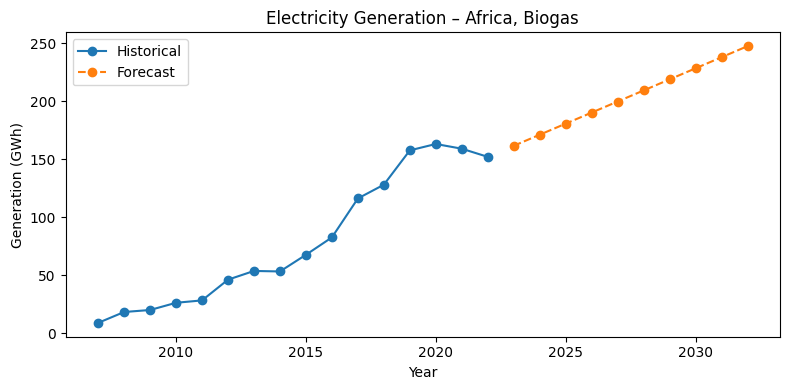

In [9]:
import matplotlib.pyplot as plt

def plot_region_tech(region, tech, data=forecast_df):
    df_rt = data[(data["Region"] == region) & (data["Technology"] == tech)].copy()
    if df_rt.empty:
        print(f"No data for ({region}, {tech})")
        return

    df_rt = df_rt.sort_values("Year")
    history = df_rt[df_rt["kind"] == "history"]
    forecast = df_rt[df_rt["kind"] == "forecast"]

    plt.figure(figsize=(8, 4))
    plt.plot(history["Year"], history["generation_gwh"], marker="o", label="Historical")
    if not forecast.empty:
        plt.plot(forecast["Year"], forecast["generation_gwh"], marker="o", linestyle="--", label="Forecast")
    plt.title(f"Electricity Generation – {region}, {tech}")
    plt.xlabel("Year")
    plt.ylabel("Generation (GWh)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: change these to any actual combinations in your dataset
example_region = "Africa"
example_technology = "Biogas"   # or "Solar photovoltaic", etc.
plot_region_tech(example_region, example_technology)

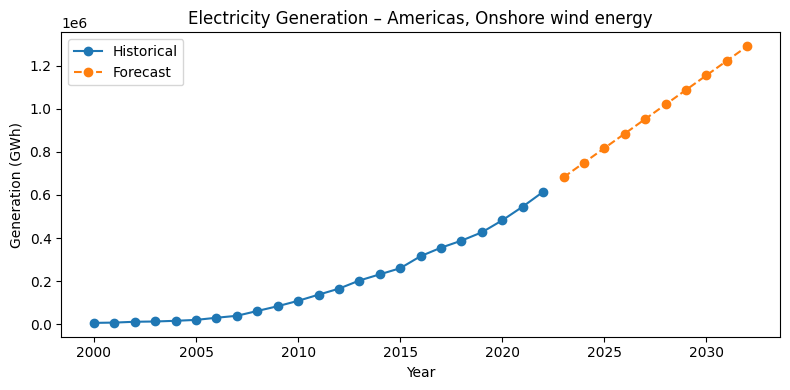

In [29]:
plot_region_tech("Americas", "Onshore wind energy")

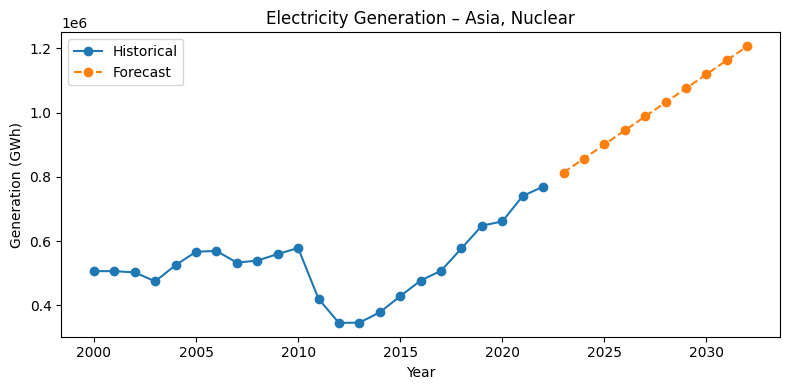

In [30]:
plot_region_tech("Asia", "Nuclear")

In [17]:
from sklearn.metrics import root_mean_squared_error

def train_test_rmse(series, test_frac=0.2):
    """
    series: DataFrame with columns [Year, generation]
    """
    y = series.sort_values("Year")["generation_gwh"].values

    n = len(y)
    split = int((1 - test_frac) * n)

    train, test = y[:split], y[split:]

    if len(train) < 3:
        return np.nan

    model = ExponentialSmoothing(train, trend="add", seasonal=None)
    fit = model.fit()

    preds = fit.forecast(len(test))

    rmse = root_mean_squared_error(test, preds)
    return rmse

In [18]:
rmse_results = []

for (region, tech), grp in ts_df.groupby(["Region","Technology"]):

    rmse = train_test_rmse(grp)

    rmse_results.append({
        "Region": region,
        "Technology": tech,
        "RMSE_TrainTest": rmse
    })

rmse_tt_df = pd.DataFrame(rmse_results)

rmse_tt_df.head()

,Region,Technology,RMSE_TrainTest
0,Africa,Biogas,15.050792
1,Africa,Coal and peat,9482.204322
2,Africa,Fossil fuels n.e.s.,2629.376455
3,Africa,Geothermal energy,296.071523
4,Africa,Liquid biofuels,4.081054


In [21]:
def rolling_rmse(series, min_train_size=5):
    """
    Walk-forward validation RMSE

    series: DataFrame with columns [Year, generation]
    """
    y = series.sort_values("Year")["generation_gwh"].values

    n = len(y)
    errors = []

    for t in range(min_train_size, n):

        train = y[:t]
        test  = y[t]

        # Need at least 3 points for trend model
        if len(train) < 3:
            continue

        model = ExponentialSmoothing(train, trend="add", seasonal=None)
        fit = model.fit()

        pred = fit.forecast(1)[0]

        errors.append((test - pred)**2)

    if not errors:
        return np.nan

    rmse = np.sqrt(np.mean(errors))
    return rmse

In [22]:
rolling_results = []

for (region, tech), grp in ts_df.groupby(["Region","Technology"]):

    rmse = rolling_rmse(grp)

    rolling_results.append({
        "Region": region,
        "Technology": tech,
        "RMSE_Rolling": rmse
    })

rmse_roll_df = pd.DataFrame(rolling_results)
rmse_roll_df.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1386: RuntimeWarning: invalid value encountered in sca

,Region,Technology,RMSE_Rolling
0,Africa,Biogas,16.836818
1,Africa,Coal and peat,16796.244556
2,Africa,Fossil fuels n.e.s.,4978.885257
3,Africa,Geothermal energy,448.408014
4,Africa,Liquid biofuels,2.198322


from matplotlib import pyplot as plt
_df_0['RMSE_Rolling'].plot(kind='hist', bins=20, title='RMSE_Rolling')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('Technology').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['RMSE_Rolling'].plot(kind='line', figsize=(8, 4), title='RMSE_Rolling')
plt.gca().spines[['top', 'right']].set_visible(False)

...

from matplotlib import pyplot as plt
_df_11['RMSE_Rolling'].plot(kind='line', figsize=(8, 4), title='RMSE_Rolling')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_12['Technology'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_12, x='index', y='Technology', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_13['Technology'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_13, x='RMSE_Rolling', y='Technology', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

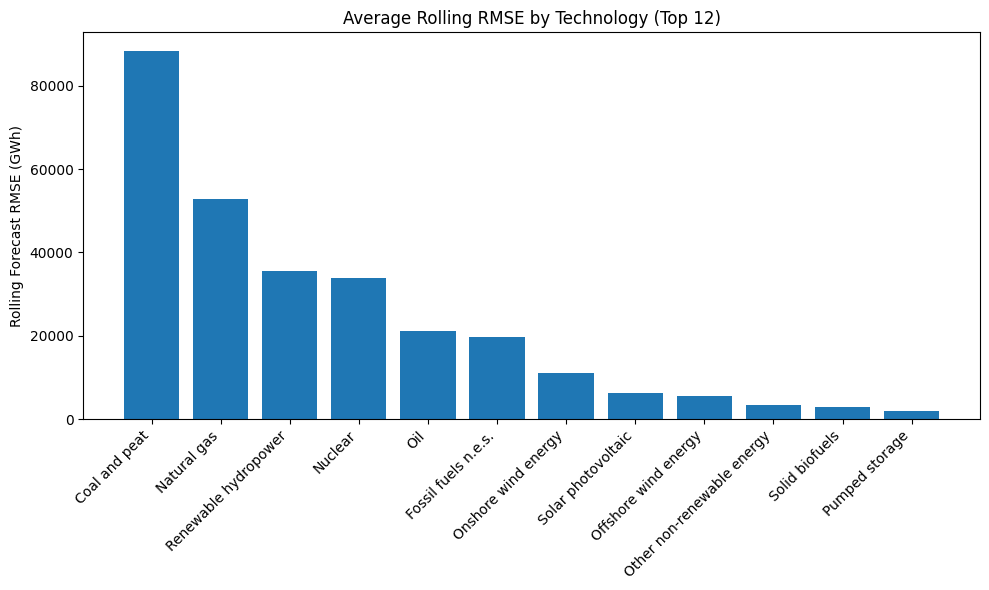

,RMSE_Rolling
Technology,
Coal and peat,88443.519590
Natural gas,52868.311893
Renewable hydropower,35506.179281
Nuclear,33948.033842
Oil,21130.085396
Fossil fuels n.e.s.,19613.887095
Onshore wind energy,10978.202480
Solar photovoltaic,6367.186226
Offshore wind energy,5485.281202


In [25]:
tech_rmse = (
    rmse_roll_df.groupby("Technology")["RMSE_Rolling"]
           .mean()
           .sort_values(ascending=False)
           .head(12)
)

# Plot
plt.figure(figsize=(10,6))
plt.bar(tech_rmse.index, tech_rmse.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rolling Forecast RMSE (GWh)")
plt.title("Average Rolling RMSE by Technology (Top 12)")
plt.tight_layout()
plt.show()

tech_rmse

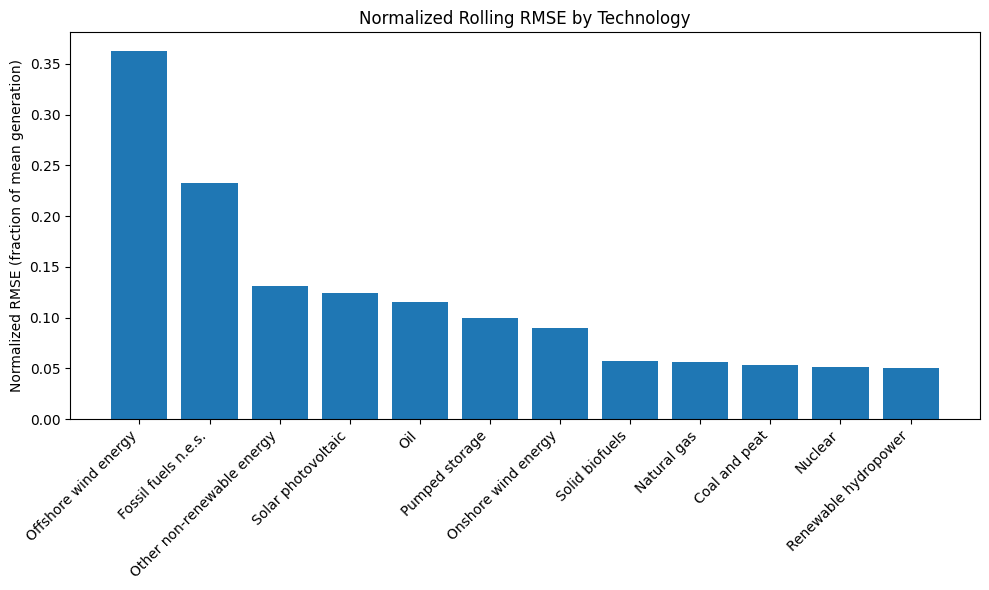

In [28]:
avg_gen = (
    ts_df.groupby("Technology")["generation_gwh"]
         .mean()
)

# Join with RMSE table
norm_df = tech_rmse.to_frame("RMSE").join(avg_gen)
norm_df["NRMSE"] = norm_df["RMSE"] / norm_df["generation_gwh"]

# Sort by normalized error
norm_df = norm_df.sort_values("NRMSE", ascending=False)

# Plot normalized RMSE
plt.figure(figsize=(10,6))
plt.bar(norm_df.index, norm_df["NRMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Normalized RMSE (fraction of mean generation)")
plt.title("Normalized Rolling RMSE by Technology")
plt.tight_layout()
plt.show()